In [74]:
from astropy.io import ascii, fits
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import seaborn as sns
from spectral_cube import SpectralCube
import astropy.units as u
from matplotlib.ticker import ScalarFormatter

In [62]:
nu11 = 23.6944955e9
size_scale_factor = 1.5
linewidth_scale_factor = 2.5

Cube = SpectralCube.read('/home/scratch/hfwest/Pilot/Data/Pilot_NH3_11_cropped.fits').with_spectral_unit(u.km/u.s, velocity_convention = 'radio')
hdr = Cube.header
x_pixel_width = abs(hdr['CDELT1']) # Pixel size in degrees (pixel width of x axis, longitude)
v_channel_width = abs(hdr['CDELT3']) # Channel width (km/s) (channel width of v axis, velocity)

def expFunc(x, a, b):
    return a * np.power(x, b)

def ratios_to_radius(Volume: float, a: float, b: float, c: float):
    R1 = b/a
    R2 = c/a
    arg = (3 * Volume) / (4 * np.pi * R1 * R2)
    return pow(arg, 1/3) # returns pixel radius in 'a' dimension

In [63]:
print(v_channel_width)

0.7238786093363


In [64]:
hdul = fits.open("/home/scratch/hfwest/Pilot/Results_ClumpFind/Pilot_07_cat.FIT")
pilot_table = Table(hdul[1].data)
pilot_table['Linear Size (pc)'] = np.zeros(len(pilot_table))
pilot_table['sigma (km/s)'] = np.zeros(len(pilot_table))
for row in pilot_table:
    row['Linear Size (pc)'] = ratios_to_radius(row['Volume'], max(row['Size1'], row['Size2']), min(row['Size1'], row['Size2']), row['Size3']) * 2 * x_pixel_width * (np.pi/180) * 7000 * size_scale_factor # Assumed distance to midpoint cloud: 7 kpc --> now in pc
    row['sigma (km/s)'] = row['Size3'] * v_channel_width * linewidth_scale_factor / (2 * np.sqrt(2 * np.log(2)))
pilot_table

PIDENT,Peak1,Peak2,Peak3,Cen1,Cen2,Cen3,Size1,Size2,Size3,Sum,Peak,Volume,Linear Size (pc),sigma (km/s)
int32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,163.5,44.5,193.5,163.53751281545334,44.52370131196119,193.88510487927687,2.1780802810536106,1.7730831161856189,4.047538935438311,360.5519726162275,1.6176305723032434,825.0,4.644093944195635,3.1105634398711612
2,66.5,66.5,167.5,65.86973328980196,65.42761175145944,168.8171908930256,3.234020553652134,3.446210490158464,3.057563401202309,1009.7945748137349,1.5137749714504212,2376.0,8.062648581447542,2.3497599609472553
3,149.5,34.5,201.5,149.29992658980714,35.84834116759818,204.8743307254102,1.9833338397281017,3.1002450378339863,4.706436590898205,438.61242585915375,1.4119234086414716,971.0,5.68392336722289,3.6169311340137806
4,101.5,25.5,197.5,101.35880616408315,23.52025174607809,198.71828922406831,3.7116963417088433,3.636550197939117,4.731209304230365,944.1995788253564,1.3553769175248795,2883.0,7.512475325159858,3.63596914640268
5,172.5,56.5,183.5,171.68753629612405,56.87896904704672,183.12255914936165,1.826733230047022,2.659646025257241,3.70205205602712,241.51981142750176,1.3467910257252391,923.0,5.618034191621136,2.8450542321295305
6,158.5,46.5,194.5,157.35991302178434,46.2325353528956,195.1185667282837,2.4995013659510588,2.5749783824276635,3.426410912547661,550.1211555013255,1.2994640311270238,1183.0,5.520183314470692,2.6332219861381434
7,165.5,50.5,194.5,166.59151944754404,52.71485515762439,196.36499522017283,3.312758126856231,3.409126057071324,2.9851258180421754,443.4724076094201,1.245732482864191,1507.0,6.877376535139008,2.2940911455400133
8,168.5,56.5,185.5,168.01880739350398,56.94980618768306,187.6153773607143,2.362272854371914,2.64432217029425,3.6804531367663063,595.2307956457493,1.2281599140001231,1275.0,5.732045860584138,2.8284553038264137
9,132.5,29.5,211.5,135.62533004297455,30.295110780529154,213.86798568894247,5.038473068473088,2.36339951107686,5.291550188842507,330.04999439721524,1.2124266181400265,1140.0,7.518560389607661,4.066595237304223


In [65]:
ramps_table = ascii.read('/users/hfwest/GBO-REU/Data/RAMPS_cleaned.csv')
ramps_table

l,b,Linear Size (pc),sigma (km/s)
float64,float64,float64,float64
9.612,0.142,2.3864112030245943,0.314694522311
9.623,0.191,5.3133799197117835,0.83105567403
9.629,0.266,1.1929340623080675,0.333130734574
9.634,0.298,0.7400928202292074,0.224414712996
9.649,-0.017,1.8243493536347024,0.319746510224
9.662,0.264,2.586392766502899,0.330921630441
9.69,-0.003,1.487332862537587,0.428652790448
9.698,-0.111,5.5215555638074925,0.650161586359
9.701,-0.224,3.832945962848816,0.549691520273


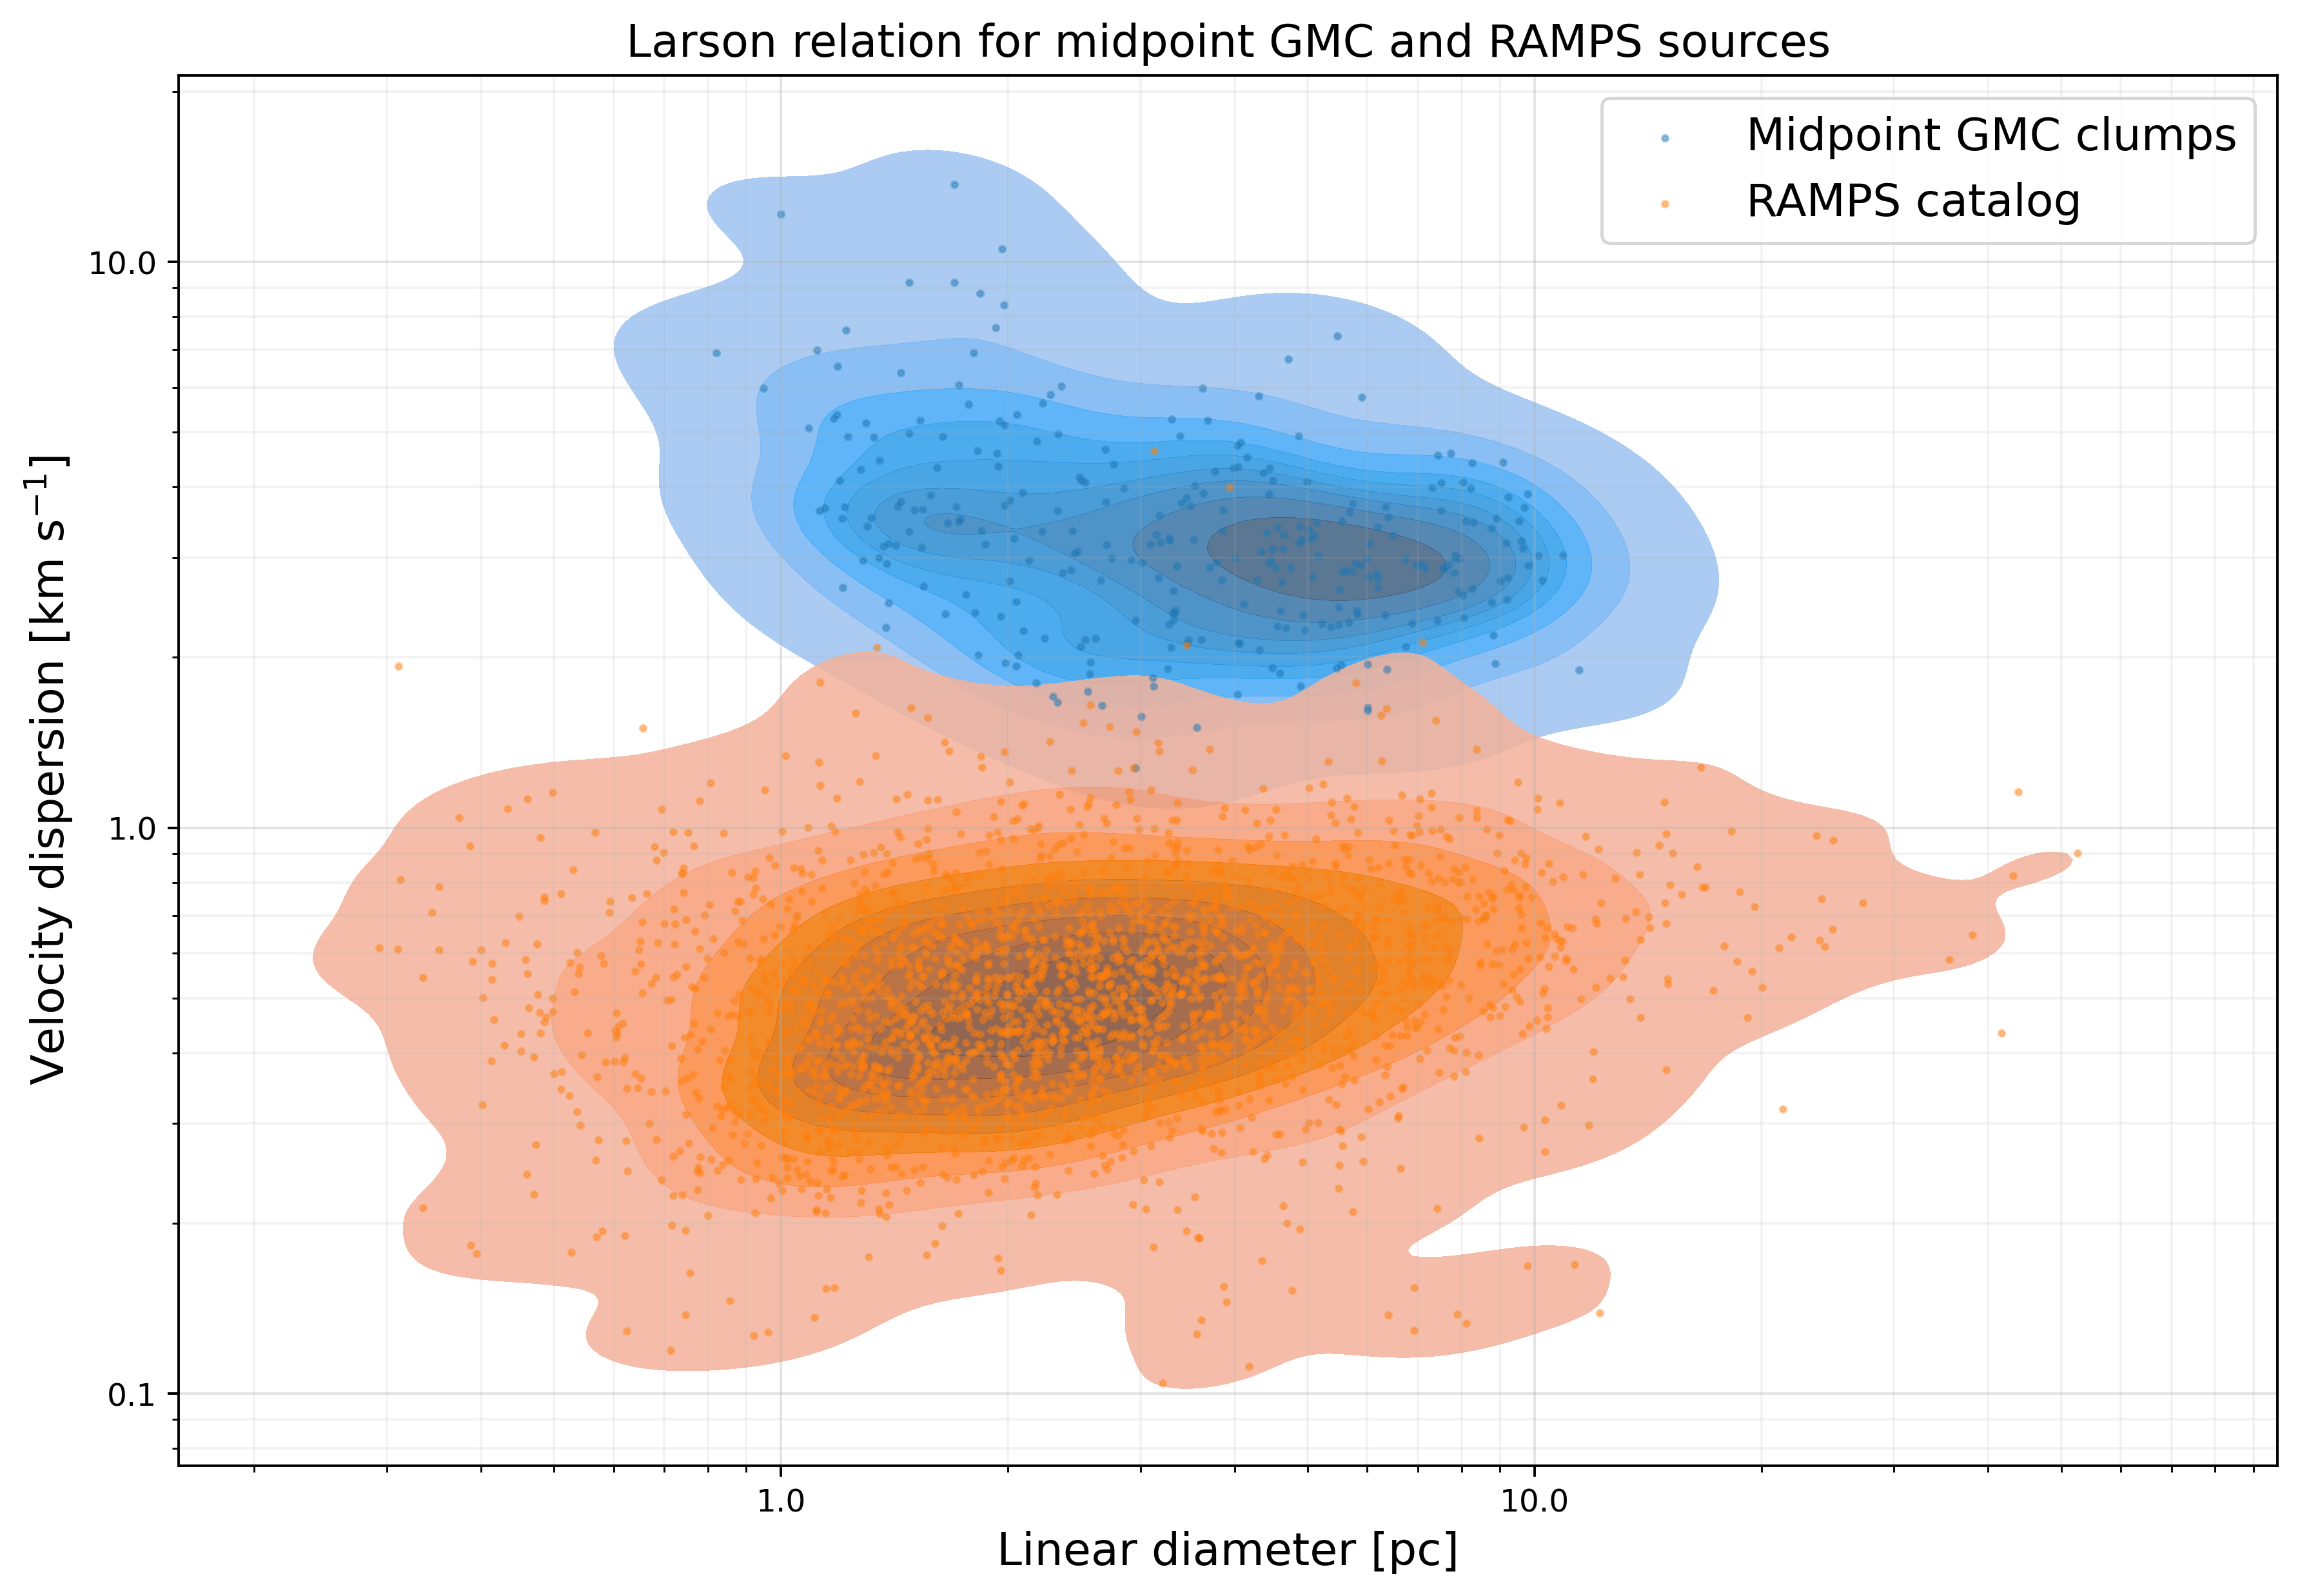

In [115]:
plt.figure(figsize= (12, 8), dpi= 350)

plt.loglog()

sns.kdeplot(x = pilot_table['Linear Size (pc)'], y = pilot_table['sigma (km/s)'], fill= True, thresh= 0.01, alpha= 0.85)
sns.kdeplot(x = ramps_table['Linear Size (pc)'], y = ramps_table['sigma (km/s)'], fill= True, thresh= 0.01, alpha= 0.85)

# pilotopt, pilotcov = curve_fit(expFunc, pilot_table['Linear Size (pc)'], pilot_table['sigma (km/s)'])
# rampsopt, rampscov = curve_fit(expFunc, ramps_table['Linear Size (pc)'], ramps_table['sigma (km/s)'])

# plt.plot([min(pilot_table['Linear Size (pc)']), max(pilot_table['Linear Size (pc)'])], [expFunc(min(pilot_table['Linear Size (pc)']), *pilotopt), expFunc(max(pilot_table['Linear Size (pc)']), *pilotopt)], label= '%.2f(x$^{%.4f}$)' % tuple(pilotopt))
# plt.plot([min(ramps_table['Linear Size (pc)']), max(ramps_table['Linear Size (pc)'])], [expFunc(min(ramps_table['Linear Size (pc)']), *rampsopt), expFunc(max(ramps_table['Linear Size (pc)']), *rampsopt)], label= '%.2f(x$^{%.4f}$)' % tuple(rampsopt))

plt.scatter(pilot_table['Linear Size (pc)'], pilot_table['sigma (km/s)'], label = 'Midpoint GMC clumps', color= 'tab:blue', alpha=.4, s= 3)
plt.scatter(ramps_table['Linear Size (pc)'], ramps_table['sigma (km/s)'], label = 'RAMPS catalog', color= 'tab:orange', alpha = 0.4, s=3)

# plt.scatter(5.5, 3, color = 'lightblue', label = 'Midpoint GMC clumps')
# plt.scatter(2.5, .5, color = 'orange', label = 'RAMPS catalog')

plt.title('Larson relation for midpoint GMC and RAMPS sources', fontsize= 'x-large')
plt.legend(fontsize = 'x-large')
plt.xlabel('Linear diameter [pc]', fontsize = 'x-large')
plt.ylabel('Velocity dispersion [km s$^{-1}$]', fontsize = 'x-large')

ax = plt.gca()
for axis in [ax.xaxis, ax.yaxis]:
    axis.set_major_formatter(ScalarFormatter())

plt.grid(True, which= 'major', alpha= 0.35)
plt.grid(True, which= 'minor', alpha= 0.15)

plt.show()

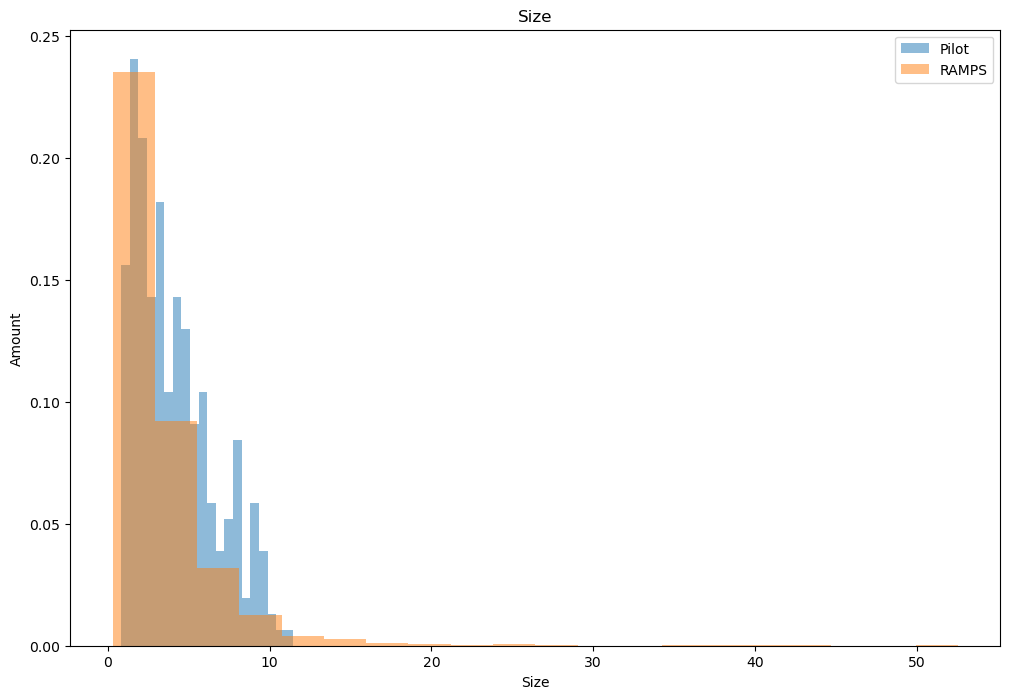

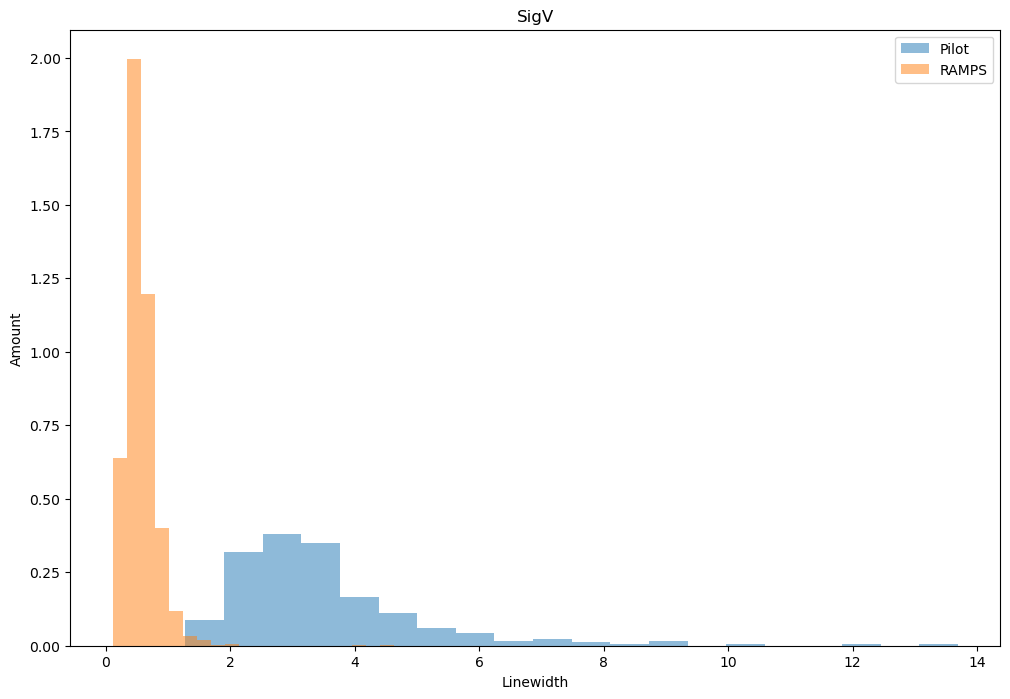

In [92]:
plt.figure(figsize= (12,8))
plt.title('Size')
plt.hist(pilot_table['Linear Size (pc)'], label= 'Pilot', alpha = 0.5, density = True, bins= 20)
plt.hist(ramps_table['Linear Size (pc)'], label= 'RAMPS', alpha = 0.5, density = True, bins= 20)
plt.legend()
# plt.yscale('log')
# ax = plt.gca()
# for axis in [ax.xaxis, ax.yaxis]:
#     axis.set_major_formatter(ScalarFormatter())
plt.xlabel('Size')
plt.ylabel('Amount')
plt.show()

plt.figure(figsize= (12,8))
plt.title('SigV')
plt.hist(pilot_table['sigma (km/s)'], label= 'Pilot', alpha = 0.5, density = True, bins= 20)
plt.hist(ramps_table['sigma (km/s)'], label= 'RAMPS', alpha = 0.5, density = True, bins= 20)
plt.legend()
# plt.yscale('log')
# ax = plt.gca()
# for axis in [ax.xaxis, ax.yaxis]:
#     axis.set_major_formatter(ScalarFormatter())
plt.xlabel('Linewidth')
plt.ylabel('Amount')
plt.show()